**개념 정리**

## 9.2 가우시안 혼합

가우시안 혼합 모델(GMM): 샘플이 파라미터가 알려지지 않은 여러 개의 혼합된 가우시안 분포에서 생성되었다고 가정하는 확률 모델
- 하나의 가우시안 분포에서 생성된 모든 샘플은 하나의 클러스터를 형성
    - 일반적으로 클러스터는 타원형
- GaussianMixture 클래스: 사전에 가우시안 분포의 개수 k를 알아야 함
- 가우시안 혼합 모델은 생성 모델, 새로운 샘플 만들기 가능
- 확률 변수 사이의 조건부 의존성의 구조

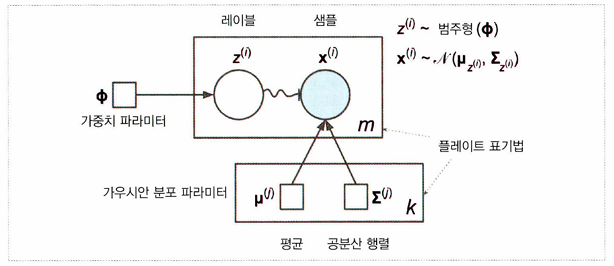

- 원: 확률 변수 / 사각형: 고정값(모델의 파라미터)
- 큰 사각형이 플레이트, 오른쪽 아래 숫자는 안의 내용이 얼마나 반복되는지 표시
- 각 변수는 가중치를 갖는 범주형 분포에서 샘플링
- 실선 화살표: 조건부 의존성 표현
- 색이 채워진 원: 알려진 값, 관측 변수

기댓값-최대화(EM) 알고리즘
- 클러스터 파라미터를 랜덤하게 초기화하고 수렴할 때까지 두 단계를 반복
- 샘플을 클러스터에 할당 (기댓값 단계) -> 클러스터 업데이트 (최대화 단계)
- k-평균과 달리 하드 클러스터 할당이 아니라 소프트 클러스터 할당을 사용
- 책임: 클러스터에 속할 추정 확률
- EM이 최적의 솔루션으로 수렴하기 어려울 떄는 학습할 파라미터 개수를 제한
    - 클러스터의 모양과 방향의 범위를 제한
        - covariance_type: spherical, diag, tied 중 하나로 설정

### 9.2.1 가우시안 혼합을 사용한 이상치 탐지

이상치 탐지: 보통과 많이 다른 샘플을 감지하는 작업
- 부정 거래 감지, 제조 결함이 있는 제품 감지 등에 사용

가우시안 혼합 모델을 이상치 탐지에 사용
- 밀도가 낮은 지역에 있는 모든 샘플을 이상치로 보기 가능
    - 밀도 임곗값을 정해야 함

특이치 탐지: 이상치로 오염되지 않은 '깨끗한' 데이터셋에서 훈련

### 9.2.2 클러스터 개수 선택하기

가우시안 혼합
- BIC나 AIC와 같은 이론적 정보 기준을 최소화하는 모델을 찾음

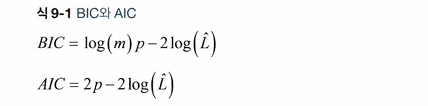

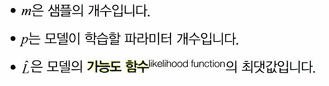

- BIC와 AIC 모두 학습할 파라미터가 많은 모델에 벌칙을 가하고 데이터에 잘 학습하는 모델에게 보상을 더함
- BIC가 선택한 모델이 AIC가 선택한 모델보다 간단한 경향
- 가능도 함수: 출력을 알고 있을 때, 특정 파라미터 값이 얼마나 그럴듯한지 설명
    - 가능도 함수는 확률 분포가 아님!!
    - 최대 가능도 추청: MLE, 최대 사후 확률: MAP
    - 가능도 함수를 최대화하는 것은 로그를 최대화하는 것과 동일


### 9.2.3 베이즈 가우시안 혼합 모델

베이즈 가우시안 혼합 모델
- BayesianGaussianMixture 클래스: 최적의 클러스터 개수를 수동으로 찾지 않고 불필요한 클러스터의 가중치를 0으로 만듦

베타 분포: 고정 범위 안에 놓인 값을 가진 확률 변수를 모델링할 때 자주 사용

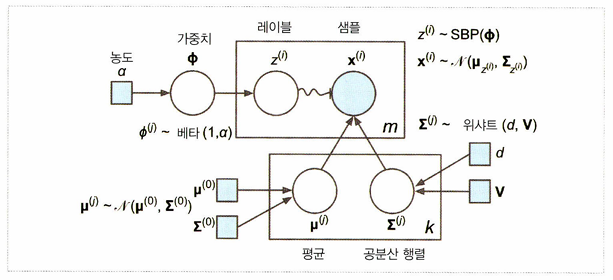

- 잠재 변수 z에 대한 사전 지식이 사전 확률이라는 확률 분포 p(z)에 인코딩 가능
    - 클러스터가 적을 것이라는 사전 믿음 갖기 가능
        - weight_concentration_prior로 조정

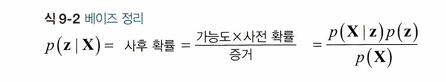

- 베이즈 정리; 데이터 X를 관측하고 난 후 잠재 변수에 대한 확률 분포를 업데이트하는 방법을 설명

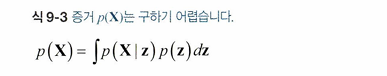

- 문제 해결
    - 변분 추론: 자체적인 변분 파라미터를 가진 분포 패밀리를 선택 -> q(z)가 p(z|X)의 좋은 근삿값이 되도록 파라미터 최적화
        - KL 발산을 최소화하려면 ELBO를 최대화

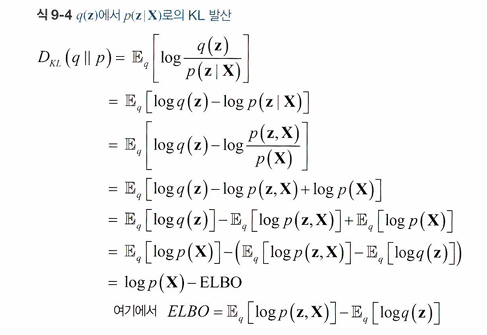

- 평균장 변분 추론: ELBO 식을 계산할 수 있는 형태로 단순화하기 위해 분포 패밀리와 사전 확률을 주의 깊게 선택
- 블랙 박스 확률적 변분 추론: 각 반복에서 몇 개의 샘플을 q에서 뽑아 변분 파라미터에 대한 ELBO의 그레이디언트를 추정하는 데 사용

### 9.2.4 이상치 탐지와 특이치 탐지를 위한 다른 알고리즘

- PCA: 보통 샘플의 재구성 오차와 이상치의 재구성 오차를 비교
- Fast-MCD: EllipticEnvelope 클래스에서 구현, 보통 샘플이 하나의 가우시안 분포에서 생성되었다고 가정
- 아이솔레이션 포레스트: 고차원 데이터셋에서 이상치 감지를 위한 효율적인 알고리즘
    - 무작위로 성장한 결정 트리로 구성된 랜덤 포레스트를 만듦
- LOF: 주어진 샘플 주위의 밀도와 이웃 주위의 밀도를 비교
- one-class SVM: 특이치 탐지에 잘 맞음

**코드 필사**

In [1]:
import numpy as np

from sklearn.datasets import make_moons
X, y=make_moons(n_samples=1000, noise=0.05)

In [2]:
from sklearn.mixture import GaussianMixture

gm=GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10)

In [3]:
gm.weights_

array([0.21045001, 0.20656025, 0.58298975])

In [4]:
gm.means_

array([[-0.72638771,  0.56766954],
       [ 1.73528846, -0.0642037 ],
       [ 0.50289341,  0.24571614]])

In [5]:
gm.covariances_

array([[[ 0.06410494,  0.06865298],
        [ 0.06865298,  0.09292454]],

       [[ 0.0575148 ,  0.06442709],
        [ 0.06442709,  0.08559713]],

       [[ 0.16209318, -0.09394552],
        [-0.09394552,  0.28219356]]])

In [6]:
gm.converged_

True

In [7]:
gm.n_iter_

16

In [8]:
gm.predict(X)

array([2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 1, 1, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2,
       0, 2, 1, 2, 2, 0, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 0, 0, 1, 1,
       0, 2, 1, 0, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1,
       2, 1, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2,
       2, 2, 2, 1, 1, 2, 0, 1, 0, 2, 2, 2, 0, 2, 0, 1, 2, 1, 1, 0, 2, 2,
       0, 0, 2, 0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 2, 0, 2, 2, 1, 2, 2, 1, 2,
       0, 2, 1, 1, 2, 2, 0, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 0,
       2, 2, 2, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 2, 0, 2, 2, 2, 2, 2, 1,
       2, 2, 0, 2, 0, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2,
       2, 0, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 0, 0, 2, 2, 0, 2,
       1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 1, 2, 1, 1, 1,

In [9]:
gm.predict_proba(X)

array([[2.84247349e-048, 5.21178549e-036, 1.00000000e+000],
       [8.82321707e-012, 1.02176811e-108, 1.00000000e+000],
       [1.32112350e-154, 9.96117826e-001, 3.88217365e-003],
       ...,
       [1.65040616e-131, 9.99348811e-001, 6.51189355e-004],
       [9.51563260e-001, 1.33070666e-225, 4.84367403e-002],
       [9.36280799e-001, 1.40764504e-208, 6.37192012e-002]])

In [10]:
X_new, y_new=gm.sample(6)
X_new

array([[-1.19858179,  0.1475604 ],
       [ 1.06884768, -0.74528301],
       [ 1.72408754,  0.03294459],
       [ 0.73654095,  0.58311794],
       [ 0.28552015,  0.46132077],
       [ 0.35339846, -0.30680977]])

In [11]:
y_new

array([0, 1, 1, 2, 2, 2])

In [12]:
gm.score_samples(X)

array([-1.44705375, -1.48468469, -1.01350155, -1.97210455, -1.9110118 ,
       -1.86336581, -1.50011261, -1.77271671, -1.70619643, -1.68760647,
       -1.7524549 , -1.9778204 , -1.80854292, -0.13386867, -0.77795338,
       -0.33075977, -1.66157319, -0.10658178, -0.13977986, -0.04277199,
       -1.41944268, -1.63762848, -1.4690132 , -1.71242039, -1.14051657,
       -1.38492425, -1.61382837, -1.92219115, -1.49808968, -0.21825047,
       -0.10286286,  0.02312929, -1.89761927, -0.45188327, -0.57263645,
       -1.8185835 , -1.39448132, -2.20311505, -2.04782985, -1.67621664,
       -0.14436534, -1.45585252, -1.59456843, -2.10863952, -1.62705193,
       -1.46006028, -2.18644441, -1.4939925 , -0.47299493, -1.86315952,
       -0.3006201 , -1.14515887, -0.46136757, -2.23763174, -1.82470628,
       -1.27894265, -1.54911657, -1.64252758, -1.01500104, -1.81662853,
       -1.60289169, -1.47134381, -1.77286845, -1.44679256, -1.49768221,
       -1.69352723, -1.5868933 , -1.5836689 , -1.47891946, -4.47

9.2.1 가우시안 혼합을 사용한 이상치 탐지

In [13]:
densities=gm.score_samples(X)
density_threshold=np.percentile(densities, 4)
anomalies=X[densities<density_threshold]

9.2.2 클러스터 개수 선택하기

In [14]:
gm.bic(X)

np.float64(2770.1670872969444)

In [15]:
gm.aic(X)

np.float64(2686.735247554248)

9.2.3 베이즈 가우시안 혼합 모델

In [16]:
from sklearn.mixture import BayesianGaussianMixture
bgm=BayesianGaussianMixture(n_components=10, n_init=10)
bgm.fit(X)
np.round(bgm.weights_,2)

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


array([0.1 , 0.11, 0.13, 0.12, 0.12, 0.18, 0.16, 0.07, 0.  , 0.  ])